In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, f1_score
from IPython.display import display, Math

# Import File

### Data Curah Hujan

In [2]:
training_hujan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\Dataset_Train_Bulanan.csv")
validation_hujan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\Dataset_Validation_Bulanan.csv")
testing_hujan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\Dataset_Testing_Bulanan.csv")

In [3]:
X_train_hujan = training_hujan[["curah_hujan"]].values
X_valid_hujan = validation_hujan[["curah_hujan"]].values
X_test_hujan = testing_hujan[["curah_hujan"]].values

In [4]:
prediksi_curah_hujan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\prediksi_curah_hujan_relu(kaggle#2).csv")

In [5]:
prediksi_curah_hujan = prediksi_curah_hujan[["Prediksi Curah Hujan"]].values

### Data Banjir

In [6]:
data_banjir_kelurahan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\data_banjir_kelurahan_fix.csv")

In [7]:
label_kelurahan = data_banjir_kelurahan.iloc[:, 1:].values
nama_kelurahan = data_banjir_kelurahan.columns[1:]

In [8]:
training_kelurahan = label_kelurahan[:int(0.6 * len (label_kelurahan))]
validasi_kelurahan = label_kelurahan[int(0.6 * len (label_kelurahan)):int(0.8 * len (label_kelurahan))]
testing_kelurahan = label_kelurahan[int(0.8 * len (label_kelurahan)):]

### Peta DKI Jakarta

In [9]:
peta_jakarta = gpd.read_file(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Peta DKI Jakarta\Fix keknya\BATAS DESA DESEMBER 2019 DUKCAPIL DKI JAKARTA\BATAS_DESA_DESEMBER_2019_DUKCAPIL_DKI_JAKARTA.shp")

# Membuat Model Regresi Logistik

In [10]:
# Buat model regresi logistik untuk kelurahan

model_regresi_logistik_kelurahan_dict = {}

print("||Untuk Dataset Training Kelurahan||")

for i, nama in enumerate(nama_kelurahan):
    y_train_daerah_kelurahan = training_kelurahan[:, i]
    if sum(y_train_daerah_kelurahan) == 0:
        model_regresi_logistik_kelurahan_dict[nama] = "Aman"
        print(f"|❌ Kelurahan {nama} tidak pernah banjir di dataset training|")
    else:
        regresi_logistik = LogisticRegression(solver="lbfgs", random_state=42)
        regresi_logistik.fit(X_train_hujan, y_train_daerah_kelurahan)
        model_regresi_logistik_kelurahan_dict[nama] = regresi_logistik
        print(f"|✅ Kelurahan {nama}|")
        
print("Udah kelar")
print("_" * 50)

||Untuk Dataset Training Kelurahan||
|✅ Kelurahan CENGKARENG BARAT|
|✅ Kelurahan CENGKARENG TIMUR|
|✅ Kelurahan DURI KOSAMBI|
|✅ Kelurahan KAPUK|
|✅ Kelurahan KEDAUNG KALI ANGKE|
|✅ Kelurahan RAWA BUAYA|
|✅ Kelurahan KALIDERES|
|✅ Kelurahan KAMAL|
|✅ Kelurahan SEMANAN|
|✅ Kelurahan PEGADUNGAN|
|✅ Kelurahan TEGAL ALUR|
|✅ Kelurahan PALMERAH|
|✅ Kelurahan DURI KEPA|
|✅ Kelurahan KEBON JERUK|
|✅ Kelurahan KEDOYA UTARA|
|✅ Kelurahan KEDOYA SELATAN|
|✅ Kelurahan KELAPA DUA|
|✅ Kelurahan SUKABUMI UTARA|
|✅ Kelurahan SUKABUMI SELATAN|
|✅ Kelurahan KEMBANGAN UTARA|
|✅ Kelurahan KEMBANGAN SELATAN|
|✅ Kelurahan JEMBATAN LIMA|
|✅ Kelurahan MERUYA SELATAN|
|✅ Kelurahan MERUYA UTARA|
|✅ Kelurahan SRENGSENG|
|✅ Kelurahan SLIPI|
|✅ Kelurahan GLODOK|
|✅ Kelurahan JOGLO|
|✅ Kelurahan TANGKI|
|✅ Kelurahan MANGGA BESAR|
|✅ Kelurahan ANGKE|
|✅ Kelurahan PEKOJAN|
|✅ Kelurahan DURI SELATAN|
|✅ Kelurahan ROA MALAKA|
|✅ Kelurahan WIJAYA KUSUMA|
|✅ Kelurahan TANJUNG DUREN SELATAN|
|✅ Kelurahan TANJUNG DUREN UT

c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Prediksi Banjir Kelurahan

In [11]:
# =========================================================================
# 1. EVALUASI DATASET TESTING KELURAHAN
# =========================================================================
print("\n" + "=" * 50)
print("|| MELAKUKAN EVALUASI PADA DATA TESTING KELURAHAN ||")
print("=" * 50)

akurasi_test_list = []
f1_test_list = []
auc_test_list = []

for i, nama in enumerate(nama_kelurahan):
    print(f"\n--- HASIL TESTING KELURAHAN {nama} ---")
    
    y_aktual = testing_kelurahan[:, i]
    model_kelurahan = model_regresi_logistik_kelurahan_dict[nama]
    
    # Logika Penanganan Kelurahan "Aman"
    if model_kelurahan == "Aman":
        y_prediksi = np.zeros(len(X_test_hujan))
        y_probabilitas = np.zeros(len(X_test_hujan))
    else:
        y_prediksi = model_kelurahan.predict(X_test_hujan)
        y_probabilitas = model_kelurahan.predict_proba(X_test_hujan)[:, 1]
    
    # Menghitung confusion matrix
    cm = confusion_matrix(y_aktual, y_prediksi, labels=[0, 1])
    print("|CONFUSION MATRIX|")
    latex_matrix = f"\\begin{{bmatrix}} TN={cm[0,0]} & FP={cm[0,1]} \\\\ FN={cm[1,0]} & TP={cm[1,1]} \\end{{bmatrix}}"
    display(Math(latex_matrix))
    
    # Menghitung Akurasi, Presisi, Recall, F1
    print("Classification Report:")
    print(classification_report(y_aktual, y_prediksi, labels=[0,1], zero_division=0))
    
    akurasi = accuracy_score(y_aktual, y_prediksi)
    f1 = f1_score(y_aktual, y_prediksi, average="macro", zero_division=0)
    akurasi_test_list.append(akurasi)
    f1_test_list.append(f1)
    
    # Menghitung AUC
    try:
        auc = roc_auc_score(y_aktual, y_probabilitas)
        print(f"AUC Score: {auc:.4f}")
        auc_test_list.append(auc)
    except ValueError:
        print("AUC Score: Tidak dapat dihitung (hanya 1 kelas di target)")


|| MELAKUKAN EVALUASI PADA DATA TESTING KELURAHAN ||

--- HASIL TESTING KELURAHAN CENGKARENG BARAT ---
|CONFUSION MATRIX|


<IPython.core.display.Math object>

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.00      0.00      0.00         2

    accuracy                           0.88        24
   macro avg       0.46      0.48      0.47        24
weighted avg       0.84      0.88      0.86        24

AUC Score: 0.9091

--- HASIL TESTING KELURAHAN CENGKARENG TIMUR ---
|CONFUSION MATRIX|


<IPython.core.display.Math object>

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.00      0.00      0.00         2

    accuracy                           0.88        24
   macro avg       0.46      0.48      0.47        24
weighted avg       0.84      0.88      0.86        24

AUC Score: 0.8636

--- HASIL TESTING KELURAHAN DURI KOSAMBI ---
|CONFUSION MATRIX|


...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.00      0.00      0.00         1

    accuracy                           0.96        24
   macro avg       0.48      0.50      0.49        24
weighted avg       0.92      0.96      0.94        24

AUC Score: 0.0435

--- HASIL TESTING KELURAHAN PULAU HARAPAN  ---
|CONFUSION MATRIX|


<IPython.core.display.Math object>

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.00      0.00      0.00         1

    accuracy                           0.96        24
   macro avg       0.48      0.50      0.49        24
weighted avg       0.92      0.96      0.94        24

AUC Score: 0.0435

--- HASIL TESTING KELURAHAN TOTAL ---
|CONFUSION MATRIX|


<IPython.core.display.Math object>

Classification Report:
              precision    recall  f1-score   support

           0       0.44      1.00      0.62         4
           1       0.00      0.00      0.00         0

   micro avg       0.44      1.00      0.62         4
   macro avg       0.22      0.50      0.31         4
weighted avg       0.44      1.00      0.62         4

AUC Score: Tidak dapat dihitung (hanya 1 kelas di target)


In [12]:
# Rata-rata evaluasi testing kelurahan
print(f"1. Rata-rata Akurasi     : {np.mean(akurasi_test_list)*100:.2f}%")
print(f"2. Rata-rata F1-Score    : {np.mean(f1_test_list):.4f}")

if len(auc_test_list) > 0:
    print(f"3. Rata-rata AUC Score   : {np.mean([n for n in auc_test_list if not np.isnan(n)]):.4f}")
else:
    print("3. Rata-rata AUC Score   : Tidak dapat dihitung")

1. Rata-rata Akurasi     : 92.06%
2. Rata-rata F1-Score    : 0.7136
3. Rata-rata AUC Score   : 0.7066


In [13]:
# =========================================================================
# 2. EVALUASI DATASET VALIDASI KELURAHAN
# =========================================================================
print("\n" + "=" * 50)
print("|| MELAKUKAN EVALUASI PADA DATA VALIDASI KELURAHAN ||")
print("=" * 50)

akurasi_valid_list = []
f1_valid_list = []
auc_valid_list = []

for i, nama in enumerate(nama_kelurahan):
    y_aktual = validasi_kelurahan[:, i]
    model_kelurahan = model_regresi_logistik_kelurahan_dict[nama]
    
    if model_kelurahan == "Aman":
        y_prediksi = np.zeros(len(X_valid_hujan))
        y_probabilitas = np.zeros(len(X_valid_hujan))
    else:
        y_prediksi = model_kelurahan.predict(X_valid_hujan)
        y_probabilitas = model_kelurahan.predict_proba(X_valid_hujan)[:, 1]
    
    akurasi = accuracy_score(y_aktual, y_prediksi)
    f1 = f1_score(y_aktual, y_prediksi, average="macro", zero_division=0)
    akurasi_valid_list.append(akurasi)
    f1_valid_list.append(f1)
    
    try:
        auc = roc_auc_score(y_aktual, y_probabilitas)
        auc_valid_list.append(auc)
    except ValueError:
        pass


|| MELAKUKAN EVALUASI PADA DATA VALIDASI KELURAHAN ||


c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Giana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ra

In [14]:
# Rata-rata evaluasi valid kelurahan
print(f"1. Rata-rata Akurasi     : {np.mean(akurasi_valid_list)*100:.2f}%")
print(f"2. Rata-rata F1-Score    : {np.mean(f1_valid_list):.4f}")

if len(auc_test_list) > 0:
    print(f"3. Rata-rata AUC Score Validasi : {np.mean([n for n in auc_valid_list if not np.isnan(n)]):.4f}")
else:
    print("3. Rata-rata AUC Score   : Tidak dapat dihitung")

1. Rata-rata Akurasi     : 90.59%
2. Rata-rata F1-Score    : 0.7062
3. Rata-rata AUC Score Validasi : 0.7450


### Prediksi Probabilitas Terjadi Banjir

In [15]:
# =========================================================================
# PREDIKSI PROBABILITAS TERJADI BANJIR DI KELURAHAN
# =========================================================================
probabilitas_banjir_kelurahan = {}

for nama in nama_kelurahan:
    model_kelurahan = model_regresi_logistik_kelurahan_dict[nama]
    if model_kelurahan == "Aman":
        prob_banjir = np.zeros(len(prediksi_curah_hujan))
    else:
        prob_banjir = model_kelurahan.predict_proba(prediksi_curah_hujan)[:, 1]
        
    probabilitas_banjir_kelurahan[nama] = prob_banjir

forecast_banjir_kelurahan = pd.DataFrame(probabilitas_banjir_kelurahan)
forecast_banjir_kelurahan.index = [f"Bulan ke-{i+1}" for i in range(len(prediksi_curah_hujan))]

display(forecast_banjir_kelurahan)

,CENGKARENG BARAT,CENGKARENG TIMUR,DURI KOSAMBI,KAPUK,KEDAUNG KALI ANGKE,RAWA BUAYA,KALIDERES,KAMAL,SEMANAN,PEGADUNGAN,...,SUNGAI BAMBU,SUNTER JAYA,WARAKAS,PULAU PARI,PULAU UNTUNG JAWA,PULAU TIDUNG,PULAU PANGGANG,PULAU KELAPA,PULAU HARAPAN,TOTAL
Bulan ke-1,0.451835,0.366641,0.420643,0.452118,0.428463,0.811939,0.122725,0.288714,0.112776,0.130100,...,0.066307,0.057829,0.098899,0.000071,0.000071,0.000071,0.000071,0.000071,0.007661,0.006452
Bulan ke-2,0.525950,0.451946,0.512648,0.502538,0.506857,0.857565,0.142462,0.324538,0.125899,0.156475,...,0.076754,0.081146,0.122142,0.000043,0.000043,0.000043,0.000043,0.000043,0.006582,0.005304
Bulan ke-3,0.437129,0.350332,0.402647,0.442095,0.413049,0.801548,0.119064,0.281822,0.110293,0.125292,...,0.064378,0.053981,0.094741,0.000078,0.000078,0.000078,0.000078,0.000078,0.007898,0.006706
Bulan ke-4,0.235308,0.151878,0.175167,0.296751,0.208423,0.589027,0.073317,0.188341,0.077478,0.068228,...,0.040415,0.018038,0.047602,0.000364,0.000364,0.000364,0.000364,0.000364,0.012656,0.011915
Bulan ke-5,0.101863,0.051736,0.057611,0.176212,0.083603,0.319280,0.042527,0.116368,0.052306,0.034301,...,0.024209,0.005383,0.022033,0.001908,0.001908,0.001908,0.001908,0.001908,0.020973,0.020739
Bulan ke-6,0.031364,0.012115,0.012634,0.083516,0.023533,0.103402,0.021057,0.060728,0.031549,0.014116,...,0.012602,0.001165,0.008214,0.015120,0.015120,0.015120,0.015120,0.015120,0.039230,0.021258


### Visualisasi Probabilitas Banjir di Kelurahan

In [16]:
data_banjir_untuk_peta = []

kondisi_hujan_ekstrem = np.max(prediksi_curah_hujan)
input_hujan = [[kondisi_hujan_ekstrem]]

# Merge nama kelurahan dan hasil akurasi di dataset testing dan hasil prediksi
for i, (nama, isi_dict) in enumerate(model_regresi_logistik_kelurahan_dict.items()):
    akurasi = akurasi_test_list[i]
    if isi_dict == "Aman":
        status_prediksi = 0
    else:
        status_prediksi = isi_dict.predict(input_hujan)[0]
        
    data_banjir_untuk_peta.append({
        "Kelurahan": nama,
        "Akurasi": akurasi,
        "Prediksi_Banjir": status_prediksi
    })
    
# Jadiin DataFrame
df_data_banjir_untuk_peta = pd.DataFrame(data_banjir_untuk_peta)

##### Merge Peta DKI dengan Data Banjir

In [17]:
print(peta_jakarta.head())
print(peta_jakarta.columns)

   OBJECT_ID   KODE_DESA            DESA      KODE     PROVINSI  \
0    25477.0  3173031006       KEAGUNGAN  317303.0  DKI JAKARTA   
1    25478.0  3173031007          GLODOK  317303.0  DKI JAKARTA   
2    25397.0  3171031003   HARAPAN MULIA  317103.0  DKI JAKARTA   
3    25400.0  3171031006    CEMPAKA BARU  317103.0  DKI JAKARTA   
4    25378.0  3101011001  PULAU PANGGANG  310101.0  DKI JAKARTA   

           KAB_KOTA               KECAMATAN      DESA_KELUR  JUMLAH_PEN  \
0     JAKARTA BARAT              TAMAN SARI       KEAGUNGAN     21609.0   
1     JAKARTA BARAT              TAMAN SARI          GLODOK      9069.0   
2     JAKARTA PUSAT               KEMAYORAN   HARAPAN MULIA     29085.0   
3     JAKARTA PUSAT               KEMAYORAN    CEMPAKA BARU     41913.0   
4  KEPULAUAN SERIBU  KEPULAUAN SERIBU UTARA  PULAU PANGGANG      6947.0   

   JUMLAH_KK  ...  PERANG_  KEPALA_  BIARAW_  WIRASWAST_  LAINNYA_12  \
0     7255.0  ...      0.0      0.0      0.0      1370.0        94.0   
1 

In [18]:
peta_jakarta["DESA"] = peta_jakarta["DESA"].astype(str).str.upper().str.strip()
df_data_banjir_untuk_peta["Kelurahan"] = df_data_banjir_untuk_peta["Kelurahan"].astype(str).str.upper().str.strip()

In [19]:
peta_final = peta_jakarta.merge(df_data_banjir_untuk_peta, left_on="DESA", right_on="Kelurahan", how="left")

In [20]:
kelurahan_gakcocok = peta_final[peta_final["Kelurahan"].isna()]
print(f"Jumlah data yang gak cocok adalah {len(kelurahan_gakcocok)}")

Jumlah data yang gak cocok adalah 39


In [21]:
# 1. Tampilkan 39 kelurahan yang namanya tidak cocok
print("Daftar Kelurahan di Peta yang gagal di-merge:")
# to_string() digunakan agar semua 39 barisnya tercetak, tidak disingkat (...)
print(kelurahan_gakcocok[["DESA", "KECAMATAN", "KAB_KOTA"]].to_string())

# 2. Tampilkan semua nama kelurahan yang ada di data prediksi Anda untuk dibandingkan
print("\n" + "="*50)
print("Daftar Nama Kelurahan di Data Prediksi (Excel) Anda:")
# Urutkan abjad agar mudah dicarinya
nama_kelurahan_aman = [str(nama) for nama in peta_final["Kelurahan"].unique()]
print(sorted(nama_kelurahan_aman))

Daftar Kelurahan di Peta yang gagal di-merge:
                 DESA       KECAMATAN         KAB_KOTA
0           KEAGUNGAN      TAMAN SARI    JAKARTA BARAT
2       HARAPAN MULIA       KEMAYORAN    JAKARTA PUSAT
12              SENEN           SENEN    JAKARTA PUSAT
13             BUNGUR           SENEN    JAKARTA PUSAT
17             CIKINI         MENTENG    JAKARTA PUSAT
25           PAPANGGO   TANJUNG PRIOK    JAKARTA UTARA
34           KALIBARU       CILINCING    JAKARTA UTARA
63         SETIA BUDI       SETIABUDI  JAKARTA SELATAN
65     KARET KUNINGAN       SETIABUDI  JAKARTA SELATAN
79            SENAYAN  KEBAYORAN BARU  JAKARTA SELATAN
102       BALEKAMBANG      KRAMATJATI    JAKARTA TIMUR
108       PINANGRANTI         MAKASAR    JAKARTA TIMUR
113      UTAN PANJANG       KEMAYORAN    JAKARTA PUSAT
115  RAWA BADAK UTARA            KOJA    JAKARTA UTARA
124         DURI PULO          GAMBIR    JAKARTA PUSAT
129            CIDENG          GAMBIR    JAKARTA PUSAT
130    PETOJO SELAT

In [22]:
# Mencari nama kelurahan di dataset excel yang tidak ada di peta jakarta
excel_names = set(peta_final["Kelurahan"].unique())
peta_names = set(peta_jakarta["DESA"].unique())

missing_in_map = excel_names - peta_names

print(f"Ada {len(missing_in_map)} kelurahan dari Excel yang TIDAK MUNCUL di peta:")
print(sorted(list(missing_in_map)))

Ada 1 kelurahan dari Excel yang TIDAK MUNCUL di peta:
[nan]


In [23]:
peta_final = peta_final[peta_final["Kelurahan"] != "nan"]

beneran_peta_final = peta_jakarta.merge(peta_final, left_on="DESA", right_on="Kelurahan", how="left")
beneran_peta_final = beneran_peta_final.set_geometry("geometry_x")

In [24]:
bulan_target = "Bulan ke-1"

df_prob_visual = forecast_banjir_kelurahan.loc[bulan_target].reset_index()
df_prob_visual.columns = ["Kelurahan", "Nilai_Probabilitas"]

peta_final_prob = peta_jakarta.merge(df_prob_visual, left_on="DESA", right_on="Kelurahan", how="left")

##### Kartogramnye

buat yang biner

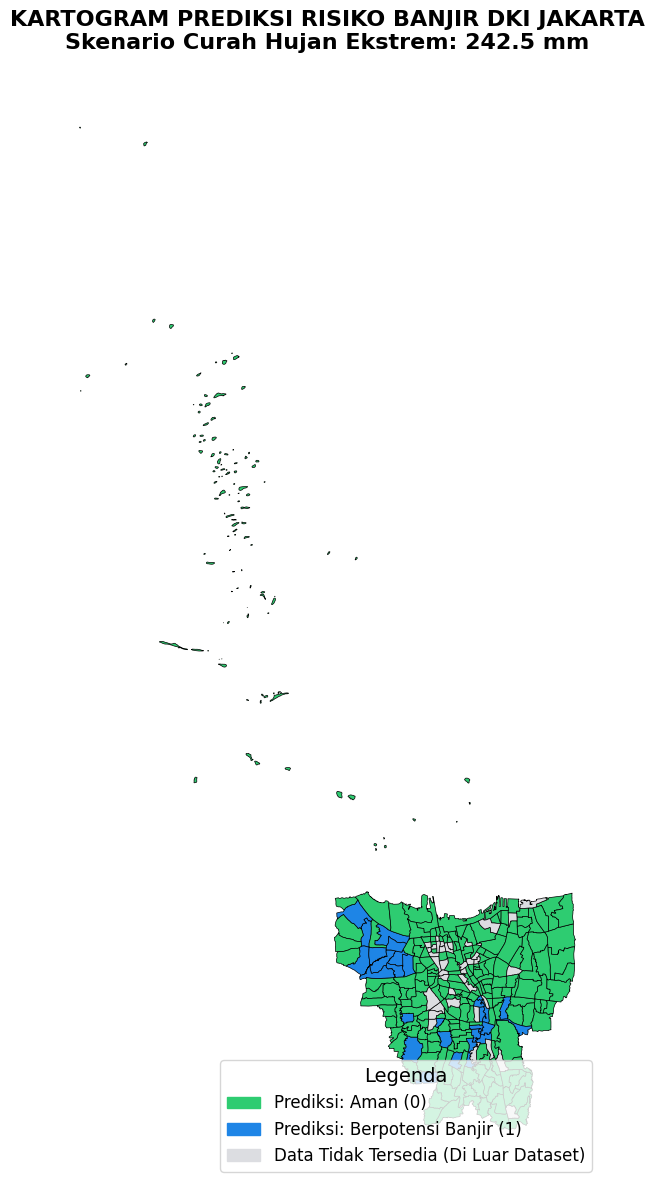

In [25]:
# Kartogram Biner

# Warna ijo = gak banjir, biru = banjir
cmap_banjir = ListedColormap(['#2ecc71', '#1e85e6'])

fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Gambar peta
beneran_peta_final.plot(column="Prediksi_Banjir", 
               cmap=cmap_banjir,
               ax=ax, 
               edgecolor="black", 
               linewidth=0.5,
               missing_kwds={
                   "color": "#dcdde1", # Warna abu-abu untuk area perairan/kosong
                   "label": "Data Tidak Tersedia"
               })

# Legend
hijau_patch = mpatches.Patch(color='#2ecc71', label="Prediksi: Aman (0)")
biru_patch = mpatches.Patch(color="#1e85e6", label="Prediksi: Berpotensi Banjir (1)")
abu_patch = mpatches.Patch(color='#dcdde1', label="Data Tidak Tersedia (Di Luar Dataset)")

plt.legend(handles=[hijau_patch, biru_patch, abu_patch], 
           loc='lower right', title="Legenda", fontsize=12, title_fontsize=14)

plt.title(f"KARTOGRAM PREDIKSI RISIKO BANJIR DKI JAKARTA\nSkenario Curah Hujan Ekstrem: {kondisi_hujan_ekstrem:.1f} mm", 
          fontsize=16, fontweight='bold', pad=20)

plt.axis("off")
plt.tight_layout()
plt.show()

buat yang probabilitas

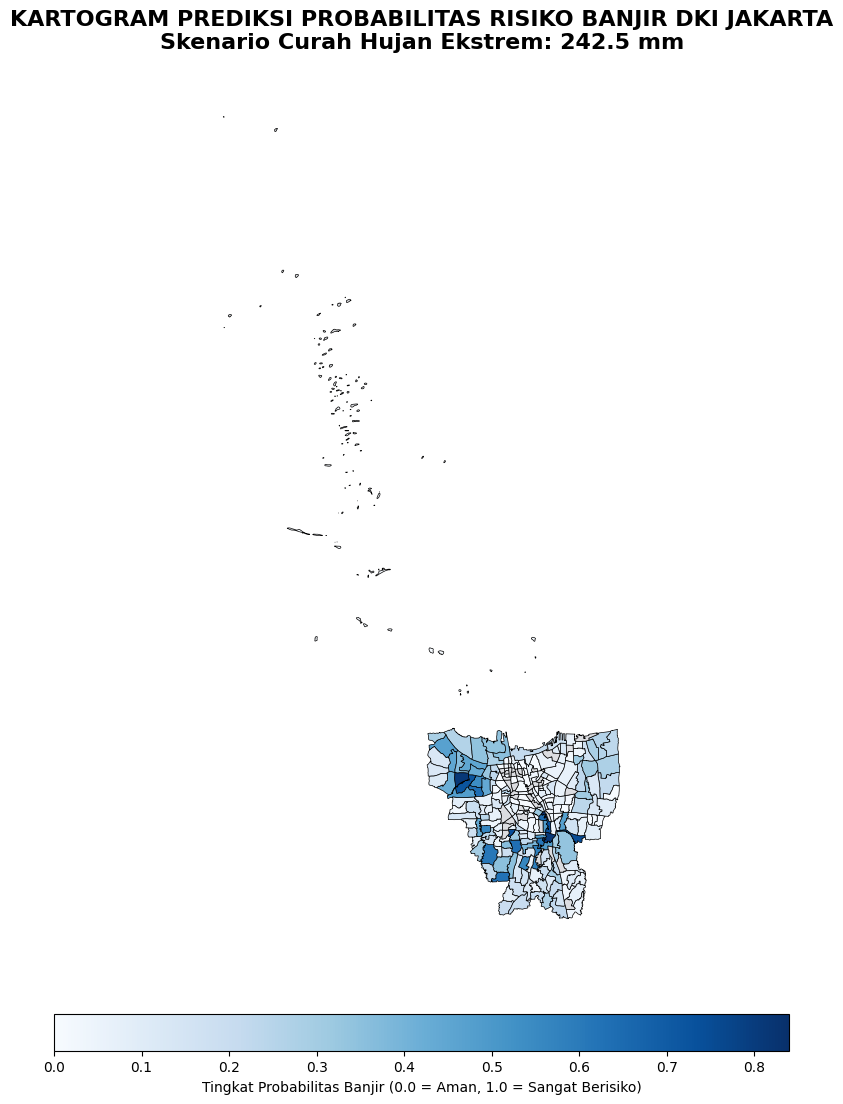

In [26]:
# Buat Probabilitas
fig, ax = plt.subplots(1, 1,figsize=(15, 12))

# Gambar peta
peta_final_prob.plot(column="Nilai_Probabilitas", 
               cmap="Blues",
               ax=ax, 
               edgecolor="black", 
               linewidth=0.5,
               legend=True,
               legend_kwds={
                   "label": "Tingkat Probabilitas Banjir (0.0 = Aman, 1.0 = Sangat Berisiko)",
                   "orientation": "horizontal", # Taruh di bawah agar mirip legend sebelumnya
                   "shrink": 0.5, # Mengecilkan ukuran batang agar tidak kepanjangan
                   "pad": 0.05
               },
               missing_kwds={
                   "color": "#dcdde1", # Warna abu-abu untuk area perairan/kosong
                   "label": "Data Tidak Tersedia"
               })

plt.title(f"KARTOGRAM PREDIKSI PROBABILITAS RISIKO BANJIR DKI JAKARTA\nSkenario Curah Hujan Ekstrem: {kondisi_hujan_ekstrem:.1f} mm", 
          fontsize=16, fontweight='bold', pad=20)

plt.axis("off")
plt.tight_layout()
plt.show()

#### Hubungan Hujan dan Banjir

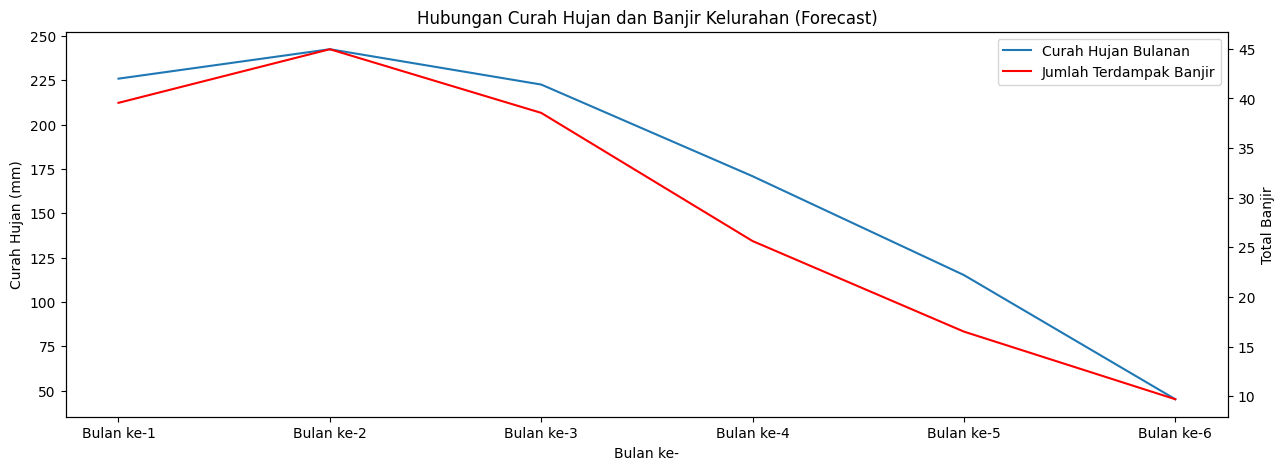

In [27]:
total_forecast_banjir_kelurahan= forecast_banjir_kelurahan.sum(axis=1)

prediksi_curah_hujan_array = np.array(prediksi_curah_hujan).flatten()

data_gabung_kelurahan = pd.DataFrame({
    "curah_hujan": prediksi_curah_hujan_array,
    "total_banjir": total_forecast_banjir_kelurahan.values
}, index=forecast_banjir_kelurahan.index)

fig1, ax11 = plt.subplots(figsize=(15, 5))
garis1 = ax11.plot(data_gabung_kelurahan.index, data_gabung_kelurahan["curah_hujan"])
ax11.set_ylabel("Curah Hujan (mm)")
ax11.set_xlabel("Bulan ke-")

ax12 = ax11.twinx()
garis2 = ax12.plot(data_gabung_kelurahan.index, data_gabung_kelurahan["total_banjir"], color="red")
ax12.set_ylabel("Total Banjir")

garis1[0].set_label("Curah Hujan Bulanan")
garis2[0].set_label("Jumlah Terdampak Banjir")

semua_garis = garis1 + garis2
semua_label = [garis.get_label() for garis in semua_garis]
ax11.legend(semua_garis, semua_label, loc="upper right")

plt.title("Hubungan Curah Hujan dan Banjir Kelurahan (Forecast)")
plt.show()

In [28]:
# Menghitung korelasi Spearman
nilai_korelasi = data_gabung_kelurahan["curah_hujan"].corr(data_gabung_kelurahan["total_banjir"], method="spearman")

print(f"Nilai Korelasi Spearman antara Curah Hujan dan Banjir: {nilai_korelasi:.3f}")

Nilai Korelasi Spearman antara Curah Hujan dan Banjir: 1.000
